# Finite-Horizon Sample-Path Bounds: IoT Remote Transmission Scheduling

A second test model for the sample-path bounds, based on **Exercise 5.4** of
[Mahajan, *Stochastic Control* notes](https://adityam.github.io/stochastic-control/mdps/intro.html#exercises)
(remote estimation / transmission scheduling for an IoT sensor).

**Model.** A sensor tracks a random walk; the receiver keeps the last transmitted value.
The sync error $S_t$ evolves as

$$S_{t+1} = \begin{cases}[S_t + W_t]_{-B}^{B} & A_t = 0 \text{ (idle)}\\ [W_t]_{-B}^{B} & A_t = 1 \text{ (transmit)}\end{cases}$$

with per-step cost $c(s,a) = \lambda a + (1-a)\,s^2$. Instead of the triangular noise pdf of the
exercise, the noise is a **centered binomial**: $W = D - n/2$ with $D \sim \text{Binomial}(n, q)$.

**Model pair** (chosen to parallel the inventory example):

| | true $M$ | approx $\hat M$ | mismatch |
|---|---|---|---|
| noise success prob. $q$ | 0.4 (drift $\mathbb{E}[W]=-1$) | 0.5 (centered) | drift mismatch (analog of the inventory demand-mean mismatch) |
| transmission cost $\lambda$ | 100 | 95 | cost mismatch $\varepsilon(s,a) = 5a$ — **action-dependent** (unlike inventory) |
| distortion cost | $s^2$ | $s^2$ | shared |
| $B$, $\gamma$, $n$, $T$ | 100, 0.75, 10, 100 | same | — |

The optimal policy is a **threshold (band) policy**: transmit iff $s \notin [k^-, k^+]$
(the analog of the inventory base-stock policy). Under the true model's downward drift the
band is asymmetric.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from matplotlib import pyplot as plt

from models import IoTModel

T = 100
print(f'Horizon T = {T},  gamma^T = {0.75**T:.2e}')

Horizon T = 100,  gamma^T = 3.21e-13


## 1. Model Definition

In [2]:
M     = IoTModel(B=100, gamma=0.75, n=10, q=0.4, lam=100.0)
M_hat = IoTModel(B=100, gamma=0.75, n=10, q=0.5, lam=95.0)

B = M.B
gamma = M.gamma
states = M.states
num_states = M.num_states
half = M.n // 2
IDX0 = B                       # index of state s = 0

print(f'State space size:  {num_states}')
print(f'Action space size: {M.num_actions}')
print(f'E[W] true   = {np.sum(M.W * np.arange(M.n + 1)) - half:.2f}')
print(f'E[W] approx = {np.sum(M_hat.W * np.arange(M_hat.n + 1)) - half:.2f}')

State space size:  201
Action space size: 2
E[W] true   = -1.00
E[W] approx = 0.00


## 2. Infinite-Horizon Solutions (for comparison)

With only two actions the Bellman operators reduce to two cheap vectorized expectations:
$\mathbb{E}[V(\mathrm{clip}(s+W))]$ (idle, a vector over $s$) and its value at $s=0$
(transmit, a scalar — the post-transmit error is pure noise).

In [3]:
# Expectation operator: EV[s] = sum_k P(D=k) V[clip(s + k - half)]
CLIP_IDX = np.clip(np.arange(num_states)[:, None]
                   + np.arange(M.n + 1)[None, :] - half, 0, num_states - 1)

def expect(V, model):
    '''E[V(clip(s + W))] as a vector over s (kernel of the given model).'''
    return V[CLIP_IDX] @ model.W


def iot_value_iteration(model, thres=1e-4):
    h = model.h_vec(model.states)
    V = np.zeros(model.num_states)
    while True:
        EV = expect(V, model)
        Q0 = h + model.gamma * EV
        Q1 = model.lam + model.gamma * EV[IDX0]
        V_new = np.minimum(Q0, Q1)
        pi = (Q1 < Q0).astype(int)
        delta = np.max(np.abs(V_new - V))
        V = V_new
        if delta < thres:
            break
    return V, pi


def iot_policy_evaluation(model, pi, thres=1e-6):
    h = model.h_vec(model.states)
    cost = model.lam * pi + (1 - pi) * h
    V = np.zeros(model.num_states)
    while True:
        EV = expect(V, model)
        V_new = cost + model.gamma * np.where(pi == 1, EV[IDX0], EV)
        delta = np.max(np.abs(V_new - V))
        V = V_new
        if delta < thres:
            break
    return V


def band(pi):
    '''Idle band [k-, k+] of a threshold policy (transmit outside).'''
    idle = np.where(pi == 0)[0]
    return int(states[idle[0]]), int(states[idle[-1]])


print('Value iteration on M (tight threshold) ...')
V_star_ih, pi_star_ih = iot_value_iteration(M, thres=1e-12)

print('Value iteration on M_hat (tight threshold) ...')
V_hat_star_ih, pi_hat_star_ih = iot_value_iteration(M_hat, thres=1e-12)

k_lo, k_hi = band(pi_star_ih)
kh_lo, kh_hi = band(pi_hat_star_ih)
print(f'True idle band:   [{k_lo}, {k_hi}]  (asymmetric under drift -1)')
print(f'Approx idle band: [{kh_lo}, {kh_hi}]')
print(f'Policies differ on {np.sum(pi_star_ih != pi_hat_star_ih)} state(s)')

print('Policy evaluation: pi_hat* on M (tight threshold) ...')
V_pi_hat_ih = iot_policy_evaluation(M, pi_hat_star_ih, thres=1e-12)
gap_ih = V_pi_hat_ih - V_star_ih
print(f'Max gap = {np.max(gap_ih):.4f} at s = {states[np.argmax(gap_ih)]:.0f}')

Value iteration on M (tight threshold) ...
Value iteration on M_hat (tight threshold) ...
True idle band:   [-6, 7]  (asymmetric under drift -1)
Approx idle band: [-6, 6]
Policies differ on 1 state(s)
Policy evaluation: pi_hat* on M (tight threshold) ...
Max gap = 25.3251 at s = 7


### Sup-Norm and Weighted-Norm Bounds (infinite horizon)

Same construction as the inventory notebook, with weight $w(s) = 1 + \ell\, s^2$
(the IoT analog of $1 + \ell\, h(s)$) and
$\kappa = \max$ over the pairs $(M,\pi^\star)$, $(M,\hat\pi^\star)$, $(\hat M,\hat\pi^\star)$.

Unlike the inventory model, here the mismatches are essentially **bounded**: the cost mismatch
$5a$ is bounded, and outside the idle band both policies transmit, so the transition mismatch
does not grow with $|s|$. Consequently the weighting **does not help** — the scan below shows
the bound is minimized as $\ell \to 0$ (recovering the sup-norm bound). We keep a small
$\ell = 10^{-3}$ for the weighted curve to display a genuinely different (but looser) bound.

In [4]:
def iot_weight_function(model, ell):
    return 1 + ell * model.h_vec(model.states)


def iot_compute_kappa(model, weight, pi):
    Ew = expect(weight, model)
    lhs = np.where(pi == 1, Ew[IDX0], Ew)
    return np.max(lhs / weight)


def iot_bellman_opt_step(V, model):
    h = model.h_vec(model.states)
    EV = expect(V, model)
    return np.minimum(h + model.gamma * EV, model.lam + model.gamma * EV[IDX0])


def iot_bellman_pi_step(V, pi, model):
    h = model.h_vec(model.states)
    EV = expect(V, model)
    cost = model.lam * pi + (1 - pi) * h
    return cost + model.gamma * np.where(pi == 1, EV[IDX0], EV)


def iot_weighted_norm_bound(V_hat_star, pi_hat_star, weight, M, M_hat, kappa):
    mismatch_opt = np.max(np.abs(iot_bellman_opt_step(V_hat_star, M)
                                  - iot_bellman_opt_step(V_hat_star, M_hat)) / weight)
    mismatch_pi = np.max(np.abs(iot_bellman_pi_step(V_hat_star, pi_hat_star, M)
                                 - iot_bellman_pi_step(V_hat_star, pi_hat_star, M_hat)) / weight)
    return (1 / (1 - M.gamma * kappa)) * (mismatch_opt + mismatch_pi)


def kappa_all_pairs(weight):
    return max(iot_compute_kappa(M, weight, pi_star_ih),
               iot_compute_kappa(M, weight, pi_hat_star_ih),
               iot_compute_kappa(M_hat, weight, pi_hat_star_ih))


# Sup-norm bound (weight = 1)
w_sup = iot_weight_function(M_hat, 0)
kappa_sup = kappa_all_pairs(w_sup)
bound_sup = iot_weighted_norm_bound(V_hat_star_ih, pi_hat_star_ih, w_sup, M, M_hat, kappa_sup)
sup_bound_curve = bound_sup * w_sup
print(f'Sup-norm bound = {bound_sup:.4f}  (kappa = {kappa_sup:.4f})')

# ell scan: weighting does not help for this model
print('\nell scan (max weighted curve in [-15, 15]):')
r15 = slice(B - 15, B + 15 + 1)
for ell in [1e-4, 1e-3, 5e-3, 1.5e-2, 5e-2]:
    w = iot_weight_function(M_hat, ell)
    kap = kappa_all_pairs(w)
    if gamma * kap >= 1:
        print(f'  ell = {ell:.0e}: gamma*kappa = {gamma*kap:.3f} >= 1 (invalid)')
        continue
    b = iot_weighted_norm_bound(V_hat_star_ih, pi_hat_star_ih, w, M, M_hat, kap)
    print(f'  ell = {ell:.0e}: kappa = {kap:.4f}, scalar = {b:8.2f}, '
          f'max curve = {np.max((b * w)[r15]):8.2f}')

# Weighted-norm bound (kept for comparison plots)
ell_w = 1e-3
w_w = iot_weight_function(M_hat, ell_w)
kappa_w = kappa_all_pairs(w_w)
bound_w = iot_weighted_norm_bound(V_hat_star_ih, pi_hat_star_ih, w_w, M, M_hat, kappa_w)
weighted_bound_curve = bound_w * w_w
print(f'\nWeighted-norm scalar = {bound_w:.4f}  (ell = {ell_w}, kappa = {kappa_w:.4f})')

Sup-norm bound = 100.7752  (kappa = 1.0000)

ell scan (max weighted curve in [-15, 15]):
  ell = 1e-04: kappa = 1.0015, scalar =   101.08, max curve =   103.35
  ell = 1e-03: kappa = 1.0149, scalar =   103.82, max curve =   127.18
  ell = 5e-03: kappa = 1.0653, scalar =   116.28, max curve =   247.10
  ell = 1e-02: kappa = 1.1500, scalar =   156.55, max curve =   684.92
  ell = 5e-02: kappa = 1.3241, scalar =  2443.20, max curve = 29929.21

Weighted-norm scalar = 103.8179  (ell = 0.001, kappa = 1.0149)


## 3. Finite-Horizon Backward Induction

Discount absorbed into a time-varying cost $c_t(s,a) = \gamma^{t-1}\,[\lambda a + (1-a)s^2]$;
transitions stationary.

In [5]:
def iot_fh_backward_induction(model, T):
    '''Finite-horizon MDP with time-varying costs c_t = gamma^{t-1} * c.

    Returns:
        V_all:  shape (T+2, num_states), V_all[T+1] = 0
        pi_all: shape (T+1, num_states)
    '''
    h = model.h_vec(model.states)
    V_all = np.zeros((T + 2, model.num_states))
    pi_all = np.zeros((T + 1, model.num_states), dtype=int)
    for t in range(T, 0, -1):
        g = model.gamma ** (t - 1)
        EV = expect(V_all[t + 1], model)
        Q0 = g * h + EV
        Q1 = g * model.lam + EV[IDX0]
        V_all[t] = np.minimum(Q0, Q1)
        pi_all[t] = (Q1 < Q0).astype(int)
    return V_all, pi_all


print('Backward induction on M ...')
V_M_all, pi_M_all = iot_fh_backward_induction(M, T)

print('Backward induction on M_hat ...')
V_Mhat_all, pi_Mhat_all = iot_fh_backward_induction(M_hat, T)

k1_lo, k1_hi = band(pi_M_all[1])
kh1_lo, kh1_hi = band(pi_Mhat_all[1])
print(f'FH idle bands at t=1: true [{k1_lo}, {k1_hi}], approx [{kh1_lo}, {kh1_hi}]')

Backward induction on M ...
Backward induction on M_hat ...
FH idle bands at t=1: true [-6, 7], approx [-6, 6]


### Truncation Validation

$\gamma^T \|c\|_\infty / (1-\gamma) = 0.75^{100} \cdot 10^4 / 0.25 \approx 1.3\times 10^{-8}$,
so the finite-horizon values at $t=1$ must match the infinite-horizon fixed points.

In [6]:
trunc_M = np.max(np.abs(V_M_all[1] - V_star_ih))
trunc_Mhat = np.max(np.abs(V_Mhat_all[1] - V_hat_star_ih))
print(f'Truncation error (M):     {trunc_M:.2e}')
print(f'Truncation error (M_hat): {trunc_Mhat:.2e}')
assert trunc_M < 1e-8, f'Truncation error too large: {trunc_M}'
assert trunc_Mhat < 1e-8, f'Truncation error too large: {trunc_Mhat}'
print('PASS: V_fh[1] matches V_inf to < 1e-8')

Truncation error (M):     3.01e-11
Truncation error (M_hat): 1.50e-11
PASS: V_fh[1] matches V_inf to < 1e-8


## 4. Finite-Horizon Policy Evaluation

In [7]:
def iot_fh_policy_eval(model, pi_all, T):
    '''Evaluate time-varying policy pi_all under the model's dynamics and costs.'''
    h = model.h_vec(model.states)
    V_all = np.zeros((T + 2, model.num_states))
    for t in range(T, 0, -1):
        g = model.gamma ** (t - 1)
        pi = pi_all[t]
        EV = expect(V_all[t + 1], model)
        V_all[t] = g * (model.lam * pi + (1 - pi) * h) + np.where(pi == 1, EV[IDX0], EV)
    return V_all


print('Policy evaluation: pi_hat* on M (finite horizon) ...')
V_pi_hat_fh_all = iot_fh_policy_eval(M, pi_Mhat_all, T)

gap_fh = V_pi_hat_fh_all[1] - V_M_all[1]
print(f'Max FH gap = {np.max(gap_fh):.4f} at s = {states[np.argmax(gap_fh)]:.0f}')

trunc_gap = np.max(np.abs(gap_fh - gap_ih))
print(f'|gap_fh - gap_ih|_inf = {trunc_gap:.2e}')
assert trunc_gap < 1e-7, f'Gap mismatch too large: {trunc_gap}'
print('PASS: FH gap matches IH gap')

Policy evaluation: pi_hat* on M (finite horizon) ...
Max FH gap = 25.3251 at s = 7
|gap_fh - gap_ih|_inf = 2.13e-13
PASS: FH gap matches IH gap


## 5. Backward $\alpha$-$\beta$ Recursion (Corollary 1)

Cost mismatch is **action-dependent**: $\varepsilon_t(s,a) = \gamma^{t-1}\,|\lambda-\hat\lambda|\,a = \gamma^{t-1}\cdot 5a$,
so $\varepsilon$ enters *inside* the max over actions (in the inventory model it was a
state-only prefactor). Transition mismatch
$\Delta_t(s,a) = |\sum_{s'} \hat V^\star_{t+1}(s')[P(s'|s,a) - \hat P(s'|s,a)]|$; for $a=1$
this is a scalar (post-transmit distribution is pure noise).

**Action sets.** The tightest choice is $A(s) = \{\pi^\star_t(s), \hat\pi^\star_t(s)\}$ (needs
the true policy). The **restricted** set uses only structural knowledge of the threshold-band
policy class:

- transmitting at $s = 0$ is never optimal ($a=0$ and $a=1$ give the *same* next-state
  distribution, and $c(0,0)=0 < \lambda$), so the band contains 0;
- idling is never optimal for $|s| > \bar k = \lceil\sqrt{\lambda}\rceil = 10$ (one-step saving
  $s^2 - \lambda > 0$ while transmitting also resets the error), so the band lies within
  $[-\bar k, \bar k]$.

Hence $A_{\mathrm{res}}(s) = \{0\}$ at $s=0$, $\{1\}$ for $|s| > \bar k$, and $\{0,1\}$
otherwise ($\cup\,\{\hat\pi^\star_t(s)\}$). The **sup** set is all of $\{0,1\}$. With binary
actions, $A_{\mathrm{res}}$ differs from $A_{\sup}$ only at $s=0$ and in the tails
$|s| > \bar k$ — but that difference propagates into the operating region through the
recursion.

In [8]:
# Structural validation of the restricted action set: every FH policy (both
# models, all t) must be a threshold band containing 0 and within [-10, 10].
K_BAR = 10
s_int = states.astype(int)
for t in range(1, T + 1):
    for pi in [pi_M_all[t], pi_Mhat_all[t]]:
        idle = np.where(pi == 0)[0]
        assert np.all(np.diff(idle) == 1), f'idle region not contiguous at t={t}'
        assert pi[IDX0] == 0, f'transmit at s=0 at t={t}'
        lo, hi = states[idle[0]], states[idle[-1]]
        assert -K_BAR <= lo and hi <= K_BAR, f'band [{lo},{hi}] outside +-{K_BAR} at t={t}'
print(f'PASS: all FH policies are threshold bands within [-{K_BAR}, {K_BAR}] containing 0')
print('=> A_res(s) is guaranteed to contain pi*_t(s) for all t')

PASS: all FH policies are threshold bands within [-10, 10] containing 0
=> A_res(s) is guaranteed to contain pi*_t(s) for all t


In [9]:
def iot_fh_sample_path_bound(M, M_hat, V_Mhat_all, pi_M_all, pi_Mhat_all, T,
                             K_bar=10):
    '''Finite-horizon backward alpha-beta recursion (Corollary 1).

    beta_t(s,a) = eps_t(s,a) + E_P[alpha_{t+1}](s,a) + Delta_t(s,a)
    alpha_t(s)  = max_{a in A(s)} beta_t(s,a)

    Action sets:
      max: {pi*_t(s), pi_hat*_t(s)}
      res: {1} for |s| > K_bar, {0} for s = 0, {0,1} otherwise  (+ pi_hat*_t(s))
      sup: {0, 1}

    Returns (alpha_max_all, alpha_res_all, alpha_sup_all), each (T+1, ns).
    '''
    dl = abs(M.lam - M_hat.lam)
    ns = M.num_states
    si = M.states.astype(int)
    res_has0 = np.abs(si) <= K_bar
    res_has1 = si != 0

    a_max = np.zeros((T + 1, ns))
    a_res = np.zeros((T + 1, ns))
    a_sup = np.zeros((T + 1, ns))

    # Terminal: alpha_T(s) = max_{a in A(s)} eps_T(s, a),  eps_T(s,a) = g_T*dl*a
    gT = M.gamma ** (T - 1)
    a_max[T] = gT * dl * np.maximum(pi_M_all[T], pi_Mhat_all[T])
    a_res[T] = gT * dl * np.where(res_has1 | (pi_Mhat_all[T] == 1), 1, 0)
    a_sup[T] = gT * dl

    for t in range(T - 1, 0, -1):
        g = M.gamma ** (t - 1)
        Vn = V_Mhat_all[t + 1]
        d0 = np.abs(expect(Vn, M) - expect(Vn, M_hat))   # Delta_t(s, 0), vector
        d1 = d0[IDX0]                                     # Delta_t(s, 1), scalar

        for arr, mode in [(a_max, 'max'), (a_res, 'res'), (a_sup, 'sup')]:
            EA = expect(arr[t + 1], M)
            beta0 = EA + d0                     # beta_t(s, 0)   (eps = 0)
            beta1 = g * dl + EA[IDX0] + d1      # beta_t(s, 1),  scalar
            if mode == 'max':
                b_pm = np.where(pi_M_all[t] == 1, beta1, beta0)
                b_ph = np.where(pi_Mhat_all[t] == 1, beta1, beta0)
                arr[t] = np.maximum(b_pm, b_ph)
            elif mode == 'res':
                has0 = res_has0 | (pi_Mhat_all[t] == 0)
                has1 = res_has1 | (pi_Mhat_all[t] == 1)
                arr[t] = np.maximum(np.where(has0, beta0, -np.inf),
                                    np.where(has1, beta1, -np.inf))
            else:
                arr[t] = np.maximum(beta0, beta1)
    return a_max, a_res, a_sup

In [10]:
print('Running finite-horizon alpha-beta recursion ...')
alpha_max_fh_all, alpha_res_fh_all, alpha_sup_fh_all = \
    iot_fh_sample_path_bound(M, M_hat, V_Mhat_all, pi_M_all, pi_Mhat_all, T)

alpha_max_fh = alpha_max_fh_all[1]
alpha_res_fh = alpha_res_fh_all[1]
alpha_sup_fh = alpha_sup_fh_all[1]

print(f'max 2*alpha_max_fh = {2*np.max(alpha_max_fh):.4f}')
print(f'max 2*alpha_res_fh = {2*np.max(alpha_res_fh):.4f}')
print(f'max 2*alpha_sup_fh = {2*np.max(alpha_sup_fh):.4f}')

Running finite-horizon alpha-beta recursion ...
max 2*alpha_max_fh = 79.0860
max 2*alpha_res_fh = 80.6537
max 2*alpha_sup_fh = 82.6984


### Validation

In [11]:
# Validity
slack_max = 2 * alpha_max_fh - gap_fh
slack_res = 2 * alpha_res_fh - gap_fh
slack_sup = 2 * alpha_sup_fh - gap_fh

print('=== Bound validity: 2*alpha >= gap ===')
print(f'min slack (alpha_max): {np.min(slack_max):.6f}')
print(f'min slack (alpha_res): {np.min(slack_res):.6f}')
print(f'min slack (alpha_sup): {np.min(slack_sup):.6f}')
assert np.all(slack_max >= -1e-8), 'alpha_max bound INVALID'
assert np.all(slack_res >= -1e-8), 'alpha_res bound INVALID'
assert np.all(slack_sup >= -1e-8), 'alpha_sup bound INVALID'
print('PASS: All three bounds are valid\n')

# Ordering
print('=== Ordering: alpha_max <= alpha_res <= alpha_sup ===')
print(f'max(alpha_max - alpha_res) = {np.max(alpha_max_fh - alpha_res_fh):.2e}')
print(f'max(alpha_res - alpha_sup) = {np.max(alpha_res_fh - alpha_sup_fh):.2e}')
assert np.all(alpha_max_fh <= alpha_res_fh + 1e-10), 'Ordering VIOLATED: max > res'
assert np.all(alpha_res_fh <= alpha_sup_fh + 1e-10), 'Ordering VIOLATED: res > sup'
print('PASS: Ordering holds')

=== Bound validity: 2*alpha >= gap ===
min slack (alpha_max): 41.253682
min slack (alpha_res): 44.116242
min slack (alpha_sup): 45.820736
PASS: All three bounds are valid

=== Ordering: alpha_max <= alpha_res <= alpha_sup ===
max(alpha_max - alpha_res) = -6.70e-01
max(alpha_res - alpha_sup) = -8.52e-01
PASS: Ordering holds


## 6. Plots

Operating region: after a transmit the error is pure noise in $[-5, 5]$; with the idle band
reaching $\pm 7$ the recurrent region under either policy is within about $[-12, 12]$. We zoom
to $s \in [-15, 15]$.

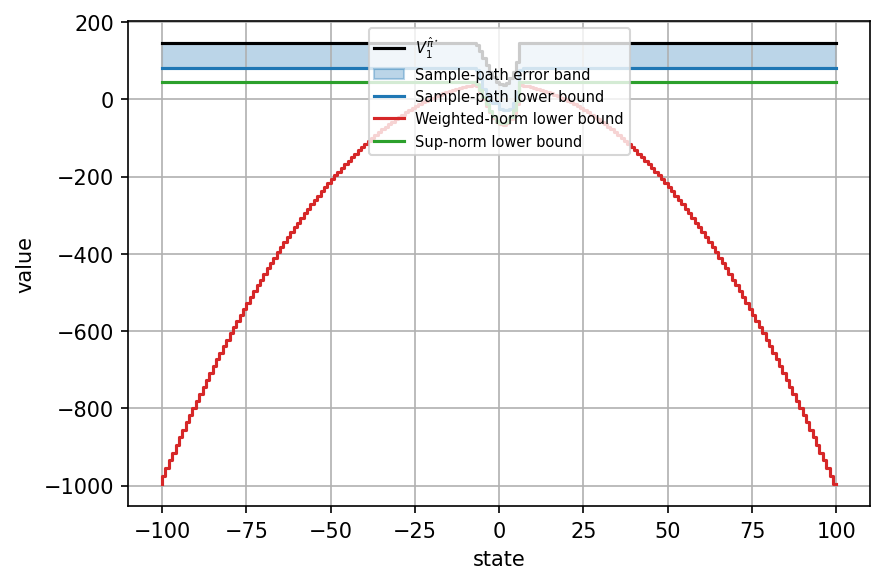

saved ../figures/iot/iot_bounds_zoomed_out.pdf


In [12]:
V_pi_hat_fh = V_pi_hat_fh_all[1]
V_star_fh = V_M_all[1]
plt.rcParams['pdf.fonttype'] = 42

# --- Figure 1a: Lower bound comparison (zoomed out, full state space) ---
xs = states
sp_lower = V_pi_hat_fh - 2 * alpha_res_fh
wn_lower = V_pi_hat_fh - weighted_bound_curve
sn_lower = V_pi_hat_fh - sup_bound_curve

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.step(xs, V_pi_hat_fh, linewidth=1.5, color='black', label=r'$V^{\hat\pi^\star}_1$')
ax.fill_between(xs, V_pi_hat_fh, sp_lower, alpha=0.30, color='#1f77b4', step='pre',
                label='Sample-path error band')
ax.step(xs, sp_lower, linewidth=1.5, color='#1f77b4', label='Sample-path lower bound')
ax.step(xs, wn_lower, linewidth=1.5, color='#d62728', label='Weighted-norm lower bound')
ax.step(xs, sn_lower, linewidth=1.5, color='#2ca02c', label='Sup-norm lower bound')
ax.set_xlabel('state')
ax.set_ylabel('value')
ax.legend(loc='upper center', fontsize=7)
ax.grid(True)
plt.tight_layout()
plt.savefig('../figures/iot/iot_bounds_zoomed_out.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('saved ../figures/iot/iot_bounds_zoomed_out.pdf')

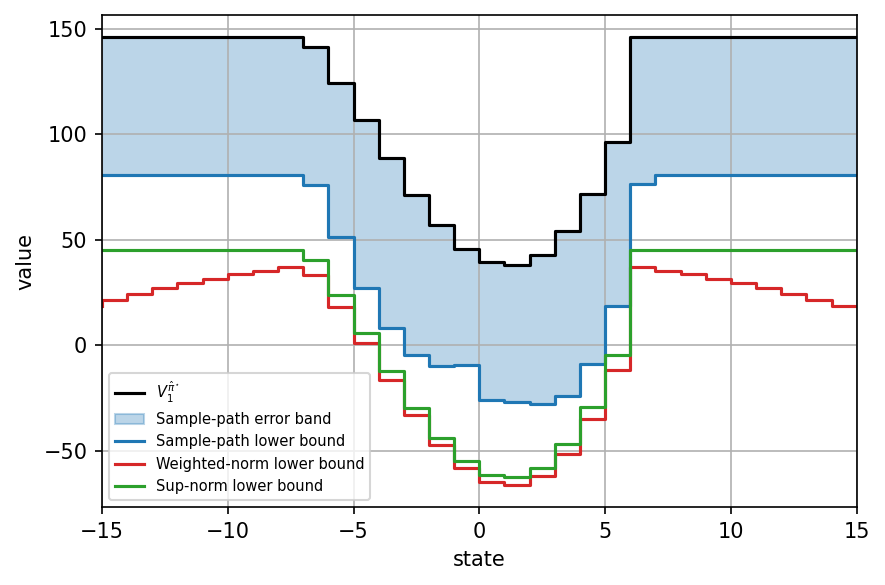

saved ../figures/iot/iot_bounds_zoomed_in.pdf


In [13]:
# --- Figure 1b: Lower bound comparison (zoomed in, operating region) ---
lo, hi = B - 15, B + 15 + 1
xs = states[lo:hi]
Vp = V_pi_hat_fh[lo:hi]

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.step(xs, Vp, linewidth=1.5, color='black', label=r'$V^{\hat\pi^\star}_1$')
ax.fill_between(xs, Vp, sp_lower[lo:hi], alpha=0.30, color='#1f77b4', step='pre',
                label='Sample-path error band')
ax.step(xs, sp_lower[lo:hi], linewidth=1.5, color='#1f77b4', label='Sample-path lower bound')
ax.step(xs, wn_lower[lo:hi], linewidth=1.5, color='#d62728', label='Weighted-norm lower bound')
ax.step(xs, sn_lower[lo:hi], linewidth=1.5, color='#2ca02c', label='Sup-norm lower bound')
ax.set_xlabel('state')
ax.set_ylabel('value')
ax.set_xlim(-15, 15)
ax.set_xticks(np.arange(-15, 16, 5))
ax.legend(loc='lower left', fontsize=7)
ax.grid(True)
plt.tight_layout()
plt.savefig('../figures/iot/iot_bounds_zoomed_in.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('saved ../figures/iot/iot_bounds_zoomed_in.pdf')

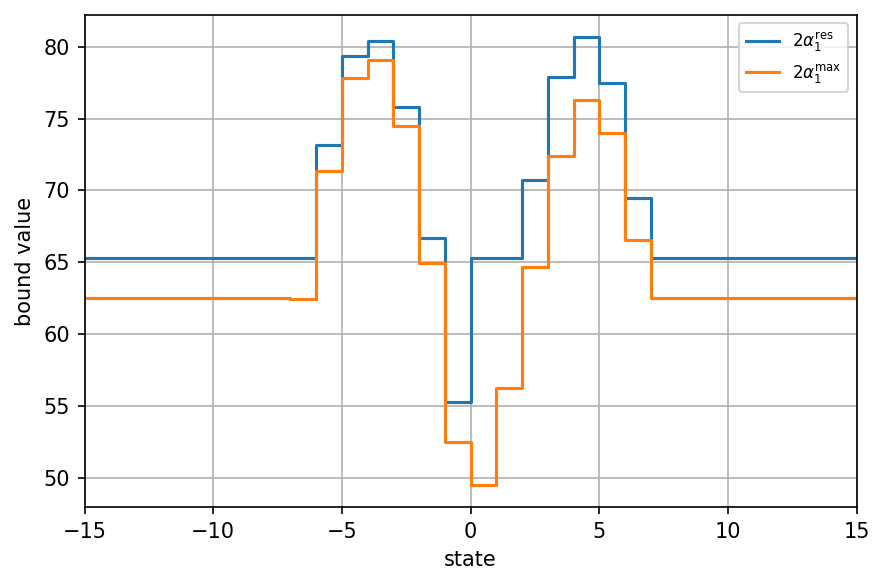

saved ../figures/iot/iot_max_vs_res.pdf


In [14]:
# --- Figure 2: 2*alpha_max vs 2*alpha_res (zoomed in) ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.step(xs, 2 * alpha_res_fh[lo:hi], linewidth=1.5, color='#1f77b4',
        label=r'$2\alpha^{\mathrm{res}}_1$')
ax.step(xs, 2 * alpha_max_fh[lo:hi], linewidth=1.5, color='#ff7f0e',
        label=r'$2\alpha^{\max}_1$')
ax.set_xlabel('state')
ax.set_ylabel('bound value')
ax.set_xlim(-15, 15)
ax.set_xticks(np.arange(-15, 16, 5))
ax.legend(loc='best', fontsize=8)
ax.grid(True)
plt.tight_layout()
plt.savefig('../figures/iot/iot_max_vs_res.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('saved ../figures/iot/iot_max_vs_res.pdf')

## 7. Summary Table

In [15]:
op_lo, op_hi = B - 15, B + 15 + 1

def region_max(arr):
    return float(np.max(arr[op_lo:op_hi]))

rows = [
    ('true gap',        region_max(gap_fh)),
    ('2*alpha_max',     region_max(2 * alpha_max_fh)),
    ('2*alpha_res',     region_max(2 * alpha_res_fh)),
    ('2*alpha_sup',     region_max(2 * alpha_sup_fh)),
    ('weighted-norm',   region_max(weighted_bound_curve)),
    ('sup-norm',        region_max(sup_bound_curve)),
]

print(f'{"quantity":<18}{"max over [-15,15]":>20}')
print('-' * 38)
for name, val in rows:
    print(f'{name:<18}{val:>20.4f}')

for s_probe in [3, 7, 10]:
    i = B + s_probe
    print(f'\ns = {s_probe}:  gap = {gap_fh[i]:.2f},  2*alpha_res = {2*alpha_res_fh[i]:.2f},  '
          f'2*alpha_max = {2*alpha_max_fh[i]:.2f},')
    print(f'        weighted-norm = {weighted_bound_curve[i]:.2f},  '
          f'sup-norm = {sup_bound_curve[i]:.2f}')

quantity             max over [-15,15]
--------------------------------------
true gap                       25.3251
2*alpha_max                    79.0860
2*alpha_res                    80.6537
2*alpha_sup                    82.6984
weighted-norm                 127.1769
sup-norm                      100.7752

s = 3:  gap = 0.19,  2*alpha_res = 70.73,  2*alpha_max = 64.63,
        weighted-norm = 104.75,  sup-norm = 100.78

s = 7:  gap = 25.33,  2*alpha_res = 69.44,  2*alpha_max = 66.58,
        weighted-norm = 108.90,  sup-norm = 100.78

s = 10:  gap = 0.01,  2*alpha_res = 65.28,  2*alpha_max = 62.47,
        weighted-norm = 114.20,  sup-norm = 100.78


## 8. Signed Sample-Path Bound (Extended Theorem 3)

Same construction as the inventory notebook, with one difference: the signed cost mismatch
$\varepsilon_t(s,a) = \gamma^{t-1}(\lambda - \hat\lambda)a = \gamma^{t-1}\cdot 5a$ is
**action-dependent**, so it moves inside the `min` of the optimality stream.

- **Policy-evaluation stream** $\alpha^{\hat\pi^\star}_t(s) = V^{\hat\pi^\star}_t - \hat V^\star_t$ — exact, anchored at $\hat\pi^\star_t(s)$.
- **Optimality stream** $\alpha^\star_t(s) = V^\star_t - \hat V^\star_t$ — sub-solution, `min` over a candidate set containing $\pi^\star_t(s)$.

Upper bound at $t = 1$: $V^{\hat\pi^\star}(s) - V^\star(s) \le U(s) = \alpha^{\hat\pi^\star}_1(s) - \alpha^\star_1(s)$,
with variants `U_max` / `U_res` / `U_sup` by candidate set (threshold-band structural set for
`res`, as in Section 5).

**Lower bound (Eq. 27) collapses to $L \equiv 0$**: the optimality super-solution is anchored
(per Eq. 26) at $\hat\pi^\star$ — the same anchor, signed mismatches, kernel, and terminal as
the policy-evaluation stream — so the two recursions are identical. Verified bit-exactly below,
exactly as in the inventory notebook.

In [16]:
def iot_fh_signed_bound(M, M_hat, V_Mhat_all, pi_M_all, pi_Mhat_all, T,
                        K_bar=10):
    '''Signed bound (Extended Thm 3): two streams sharing baseline V_hat*.

      a_ph : EXACT policy-evaluation error of pi_hat* (anchored, no search)
      a_mx / a_rs / a_sp : optimality-gap SUB-solutions, MIN over
             {pi*_t(s)} / threshold-band structural set / {0, 1}.

    eps and Delta are SIGNED; eps(s,a) = gamma^{t-1}*(lam - lam_hat)*a is
    action-dependent and sits inside the min.

    Returns (a_ph, a_mx, a_rs, a_sp), each (T+1, ns).
    '''
    dl = M.lam - M_hat.lam        # signed, = +5
    ns = M.num_states
    si = M.states.astype(int)
    res_has0 = np.abs(si) <= K_bar
    res_has1 = si != 0

    a_ph = np.zeros((T + 1, ns))
    a_mx = np.zeros((T + 1, ns))
    a_rs = np.zeros((T + 1, ns))
    a_sp = np.zeros((T + 1, ns))

    # Terminal: eps_T(s, a) = g_T * dl * a at the stream's anchor / min
    gT = M.gamma ** (T - 1)
    a_ph[T] = gT * dl * pi_Mhat_all[T]
    a_mx[T] = gT * dl * pi_M_all[T]
    a_rs[T] = gT * dl * np.where(res_has0 | (pi_Mhat_all[T] == 0), 0, 1)
    a_sp[T] = 0.0

    for t in range(T - 1, 0, -1):
        g = M.gamma ** (t - 1)
        Vn = V_Mhat_all[t + 1]
        d0 = expect(Vn, M) - expect(Vn, M_hat)   # SIGNED Delta_t(s, 0)
        d1 = d0[IDX0]                             # SIGNED Delta_t(s, 1)

        for arr, mode in [(a_ph, 'ph'), (a_mx, 'mx'), (a_rs, 'rs'), (a_sp, 'sp')]:
            EA = expect(arr[t + 1], M)
            beta0 = EA + d0                       # signed beta at a = 0
            beta1 = g * dl + EA[IDX0] + d1        # signed beta at a = 1
            if mode == 'ph':
                arr[t] = np.where(pi_Mhat_all[t] == 1, beta1, beta0)
            elif mode == 'mx':
                arr[t] = np.where(pi_M_all[t] == 1, beta1, beta0)
            elif mode == 'rs':
                has0 = res_has0 | (pi_Mhat_all[t] == 0)
                has1 = res_has1 | (pi_Mhat_all[t] == 1)
                arr[t] = np.minimum(np.where(has0, beta0, np.inf),
                                    np.where(has1, beta1, np.inf))
            else:
                arr[t] = np.minimum(beta0, beta1)
    return a_ph, a_mx, a_rs, a_sp


print('Running signed bound (Extended Theorem 3) ...')
(alpha_ph_all, alpha_star_mx_all,
 alpha_star_rs_all, alpha_star_sp_all) = iot_fh_signed_bound(
    M, M_hat, V_Mhat_all, pi_M_all, pi_Mhat_all, T)

alpha_ph = alpha_ph_all[1]

# Signed UPPER bounds  U = alpha_pihat - alpha_star
U_signed_max = alpha_ph - alpha_star_mx_all[1]
U_signed_res = alpha_ph - alpha_star_rs_all[1]
U_signed_sup = alpha_ph - alpha_star_sp_all[1]

ol, oh = B - 15, B + 15 + 1
print(f'max U_signed_max in [-15,15] = {np.max(U_signed_max[ol:oh]):.4f}')
print(f'max U_signed_res in [-15,15] = {np.max(U_signed_res[ol:oh]):.4f}')
print(f'max U_signed_sup in [-15,15] = {np.max(U_signed_sup[ol:oh]):.4f}')

# a_ph is exact: it must reproduce V^pihat - V_hat* at t=1
exact_ph = V_pi_hat_fh_all[1] - V_Mhat_all[1]
print(f'a_ph exactness: max |a_ph - (V^pihat - V_hat*)| = '
      f'{np.max(np.abs(alpha_ph - exact_ph)):.2e}')

Running signed bound (Extended Theorem 3) ...
max U_signed_max in [-15,15] = 42.4905
max U_signed_res in [-15,15] = 52.1093
max U_signed_sup in [-15,15] = 52.3622
a_ph exactness: max |a_ph - (V^pihat - V_hat*)| = 2.49e-14


In [17]:
# =====================================================================
# In-framework LOWER bound (Extended Theorem 3, Eq. 27)  --  VERIFICATION
#
# The symmetric lower bound anchors the optimality SUPER-solution (per
# Eq. 26) at pi_hat*(s). It then shares the policy-evaluation stream's
# anchor, signed eps and Delta, true kernel P, and terminal -- so the two
# recursions are identical and the computable lower bound collapses to
#       L(s) = alpha_pihat_1(s) - alpha_star^{super,pihat}_1(s) = 0.
# Below we COMPUTE the super-solution independently and check bit-exact
# equality with the policy-evaluation stream.
# =====================================================================
dl = M.lam - M_hat.lam
alpha_star_lo_all = np.zeros((T + 1, num_states))
alpha_star_lo_all[T] = (gamma ** (T - 1)) * dl * pi_Mhat_all[T]  # same terminal as a_ph

for t in range(T - 1, 0, -1):
    g = gamma ** (t - 1)
    Vn = V_Mhat_all[t + 1]
    d0 = expect(Vn, M) - expect(Vn, M_hat)                 # signed
    EA = expect(alpha_star_lo_all[t + 1], M)
    beta0 = EA + d0
    beta1 = g * dl + EA[IDX0] + d0[IDX0]
    alpha_star_lo_all[t] = np.where(pi_Mhat_all[t] == 1, beta1, beta0)  # anchor pi_hat*

# Theorem-3 in-framework lower bound on the gap V^pihat - V*
L_signed = alpha_ph - alpha_star_lo_all[1]

max_stream_diff = float(np.max(np.abs(alpha_ph_all - alpha_star_lo_all)))
bit_exact = np.array_equal(alpha_ph_all, alpha_star_lo_all)
max_abs_L = float(np.max(np.abs(L_signed)))

print('Extended Theorem 3 -- in-framework LOWER bound verification')
print(f'  max |alpha_pihat - alpha_star^super(pihat)| over all (t,s) = '
      f'{max_stream_diff:.3e}')
print(f'  streams bit-exactly identical?  {bit_exact}')
print(f'  max |L_signed| over all states  = {max_abs_L:.3e}')
print(f'  max  U_signed_res in [-15,15]    = {np.max(U_signed_res[ol:oh]):.4f}  '
      f'(upper bound, for contrast)')
print('  => in-framework Theorem-3 lower bound L(s) == 0  (verified numerically)')

Extended Theorem 3 -- in-framework LOWER bound verification
  max |alpha_pihat - alpha_star^super(pihat)| over all (t,s) = 0.000e+00
  streams bit-exactly identical?  True
  max |L_signed| over all states  = 0.000e+00
  max  U_signed_res in [-15,15]    = 52.1093  (upper bound, for contrast)
  => in-framework Theorem-3 lower bound L(s) == 0  (verified numerically)


In [18]:
# =====================================================================
# Validation of the signed bounds
# =====================================================================
gap = gap_fh

print('Signed UPPER bound validity (U - gap >= 0):')
for name, U in [('max', U_signed_max), ('res', U_signed_res), ('sup', U_signed_sup)]:
    slack = U - gap
    print(f'  {name}: min slack = {np.min(slack):.3e}   valid = {np.all(slack >= -1e-6)}')

print('\nOrdering U_max <= U_res <= U_sup:')
print(f'  max(U_max - U_res) = {np.max(U_signed_max - U_signed_res):.2e}   (<= 0)')
print(f'  max(U_res - U_sup) = {np.max(U_signed_res - U_signed_sup):.2e}   (<= 0)')
assert np.all(U_signed_max <= U_signed_res + 1e-10)
assert np.all(U_signed_res <= U_signed_sup + 1e-10)

print('\nSigned LOWER bound (Thm 3, Eq. 27) validity:')
print(f'  L == 0    : {np.all(np.abs(L_signed) < 1e-12)}   (max |L| {np.max(np.abs(L_signed)):.2e})')
print(f'  L <= gap  : {np.all(L_signed - gap <= 1e-6)}   (trivially, since L == 0)')

print('\nSigned upper vs absolute-value 2*alpha (max in [-15,15]):')
print(f'  signed U_max    = {np.max(U_signed_max[ol:oh]):.4f}')
print(f'  abs 2*alpha_max = {np.max(2*alpha_max_fh[ol:oh]):.4f}')
print(f'  signed U_res    = {np.max(U_signed_res[ol:oh]):.4f}')
print(f'  abs 2*alpha_res = {np.max(2*alpha_res_fh[ol:oh]):.4f}')

Signed UPPER bound validity (U - gap >= 0):
  max: min slack = 2.554e-03   valid = True
  res: min slack = 5.268e+00   valid = True
  sup: min slack = 5.279e+00   valid = True

Ordering U_max <= U_res <= U_sup:
  max(U_max - U_res) = -4.78e+00   (<= 0)
  max(U_res - U_sup) = -4.18e-04   (<= 0)

Signed LOWER bound (Thm 3, Eq. 27) validity:
  L == 0    : True   (max |L| 0.00e+00)
  L <= gap  : True   (trivially, since L == 0)

Signed upper vs absolute-value 2*alpha (max in [-15,15]):
  signed U_max    = 42.4905
  abs 2*alpha_max = 79.0860
  signed U_res    = 52.1093
  abs 2*alpha_res = 80.6537


In [19]:
# =====================================================================
# Summary table over the operating region [-15, 15]
# =====================================================================
def region_max(arr):
    return float(np.max(arr[ol:oh]))

rows = [
    ('true gap',               region_max(gap_fh)),
    ('signed U_max',           region_max(U_signed_max)),
    ('signed U_res',           region_max(U_signed_res)),
    ('signed U_sup',           region_max(U_signed_sup)),
    ('abs 2*alpha_max',        region_max(2 * alpha_max_fh)),
    ('abs 2*alpha_res',        region_max(2 * alpha_res_fh)),
    ('abs 2*alpha_sup',        region_max(2 * alpha_sup_fh)),
    ('signed lower L (Thm 3)', region_max(L_signed)),
]

print(f'{"quantity":<24}{"max over [-15,15]":>18}')
print('-' * 42)
for name, val in rows:
    print(f'{name:<24}{val:>18.4f}')

print('\nTightening factor (abs / signed) over [-15,15]:')
print(f'  res variant: {region_max(2*alpha_res_fh) / region_max(U_signed_res):.2f}x')
print(f'  max variant: {region_max(2*alpha_max_fh) / region_max(U_signed_max):.2f}x')

quantity                 max over [-15,15]
------------------------------------------
true gap                           25.3251
signed U_max                       42.4905
signed U_res                       52.1093
signed U_sup                       52.3622
abs 2*alpha_max                    79.0860
abs 2*alpha_res                    80.6537
abs 2*alpha_sup                    82.6984
signed lower L (Thm 3)              0.0000

Tightening factor (abs / signed) over [-15,15]:
  res variant: 1.55x
  max variant: 1.86x


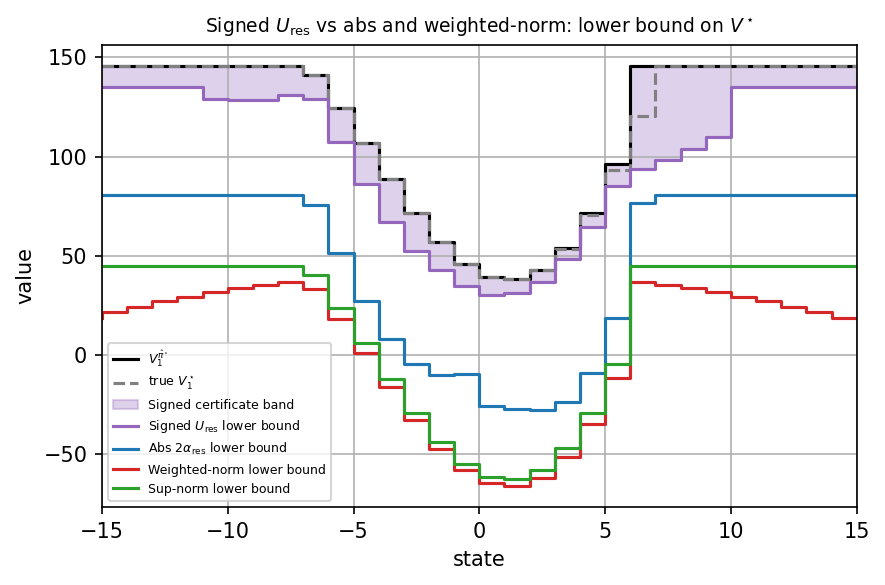

saved ../figures/iot/iot_signed_vs_abs_weighted_zoomed_in.pdf


In [20]:
# =====================================================================
# Signed certificate on V* (Extended Theorem 3, upper bound U).
#   The upper bound U on the gap certifies a LOWER bound on V*:
#       V* >= V^{pihat*}_1 - U_res.
#   (The in-framework Theorem-3 lower bound on the gap is L == 0, i.e.
#   trivial, so it is omitted here -- see the verification cell above.)
# =====================================================================
xs = states[ol:oh]
Vp = V_pi_hat_fh[ol:oh]

signed_lower = Vp - U_signed_res[ol:oh]           # signed (sample-path, no pi*)
abs_lower    = Vp - 2 * alpha_res_fh[ol:oh]       # abs value (sample-path)
wn_lower     = Vp - weighted_bound_curve[ol:oh]   # weighted-norm
sn_lower     = Vp - sup_bound_curve[ol:oh]        # sup-norm

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.step(xs, Vp, linewidth=1.5, color='black', label=r'$V^{\hat\pi^\star}_1$')
ax.step(xs, V_star_fh[ol:oh], linewidth=1.5, color='gray', linestyle='--',
        label=r'true $V^\star_1$')
ax.fill_between(xs, Vp, signed_lower, alpha=0.30, color='#9467bd', step='pre',
                label='Signed certificate band')
ax.step(xs, signed_lower, linewidth=1.5, color='#9467bd',
        label=r'Signed $U_{\mathrm{res}}$ lower bound')
ax.step(xs, abs_lower, linewidth=1.5, color='#1f77b4',
        label=r'Abs $2\alpha_{\mathrm{res}}$ lower bound')
ax.step(xs, wn_lower, linewidth=1.5, color='#d62728',
        label='Weighted-norm lower bound')
ax.step(xs, sn_lower, linewidth=1.5, color='#2ca02c',
        label='Sup-norm lower bound')

ax.set_xlabel('state')
ax.set_ylabel('value')
ax.set_title(r'Signed $U_{\mathrm{res}}$ vs abs and weighted-norm: lower bound on $V^\star$',
             fontsize=9)
ax.set_xlim(-15, 15)
ax.set_xticks(np.arange(-15, 16, 5))
ax.legend(loc='lower left', fontsize=6)
ax.grid(True)
plt.tight_layout()
plt.savefig('../figures/iot/iot_signed_vs_abs_weighted_zoomed_in.pdf',
            format='pdf', bbox_inches='tight')
plt.show()
print('saved ../figures/iot/iot_signed_vs_abs_weighted_zoomed_in.pdf')